### PCA(Principal Component Analysis)
 - 아이리스 데이터 PCA 실습

In [1]:
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(iris.data, columns = columns)
irisDF['target'] = iris.target

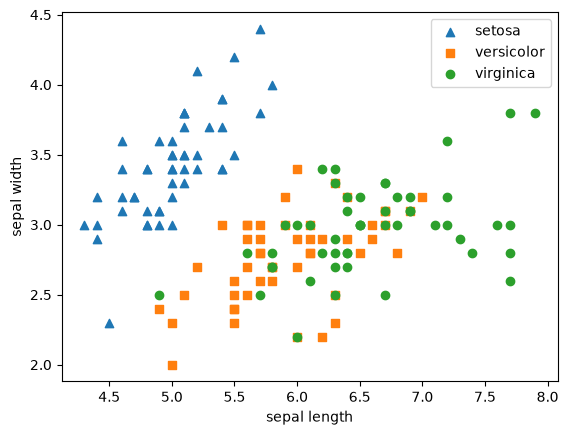

In [ ]:
markers = ['^', 's', 'o']  

for i, marker in enumerate(markers):
    x_axis_data = irisDF[irisDF['target'] == i]['sepal_length']
    y_axis_data = irisDF[irisDF['target'] == i]['sepal_width']
    plt.scatter(x_axis_data, y_axis_data, marker = marker, label = iris.target_names[i])
plt.legend()
plt.xlabel('sepal length')
plt.ylabel('sepal width')
plt.show()

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
iris_scaled = scaler.fit_transform(irisDF.iloc[:,:-1])

pca = PCA(n_components = 2)
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

In [4]:
print(iris_scaled[0])
print(iris_pca[0])

[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
[-2.26470281  0.4800266 ]


In [6]:
pca_columns = ['PC1', 'PC2']
irisDF_pca = pd.DataFrame(iris_pca, columns = pca_columns)
irisDF_pca['target'] = iris.target
irisDF_pca.head()

,PC1,PC2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


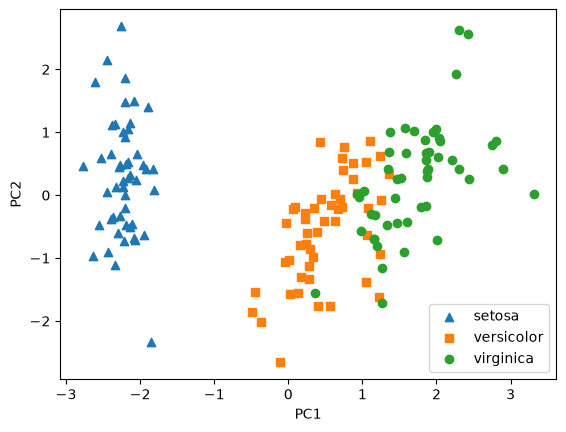

In [7]:
markers = ['^', 's', 'o']

for i, marker in enumerate(markers):
    x_axis_data = irisDF_pca[irisDF_pca['target'] == i]['PC1']
    y_axis_data = irisDF_pca[irisDF_pca['target'] == i]['PC2']
    plt.scatter(x_axis_data, y_axis_data, marker = marker, label = iris.target_names[i])
plt.legend()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

In [ ]:
# PCA 개별 변동성 비율
pca.explained_variance_ratio_

array([0.72962445, 0.22850762])

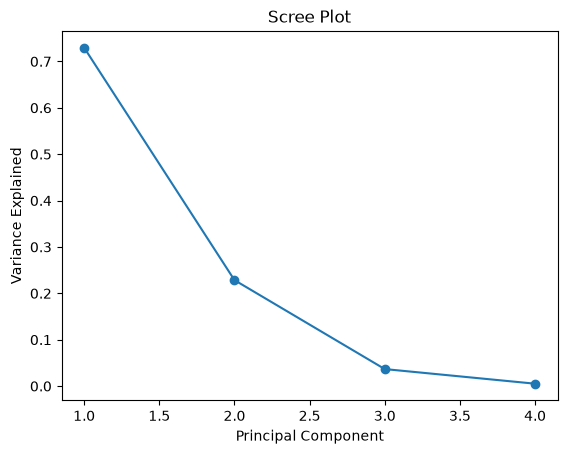

In [9]:
import numpy as np

pca = PCA(n_components = 4) # 피처 개수만큼
pca.fit(iris_scaled)
iris_pca = pca.transform(iris_scaled)

PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rcf = RandomForestClassifier(random_state=156)
scores = cross_val_score(rcf, iris.data, iris.target, scoring='accuracy', cv=3)

print('원본 데이터 교차 검증 개별 정확도:', scores)
print('원본 데이터 평균 정확도:', np.mean(scores))

원본 데이터 교차 검증 개별 정확도: [0.98 0.94 0.96]
원본 데이터 평균 정확도: 0.96


In [ ]:
pca_X = irisDF_pca[['PC1', 'PC2']]
scores_pca = cross_val_score(rcf, pca_X, iris.target, scoring='accuracy', cv=3)
print('PCA 변환 데이터 교차 검증 개별 정확도:', scores_pca)
print('PCA 변환 데이터 평균 정확도:', np.mean(scores_pca))

PCA 변환 데이터 교차 검증 개별 정확도: [0.88 0.88 0.88]
PCA 변환 데이터 평균 정확도: 0.88


### LDA(Linear Discriminant Analysis)
 - 아이리스 데이터 LDA 실습

In [1]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris
import pandas as pd
import matplotlib.pyplot as plt

iris = load_iris()
scaler = StandardScaler()
iris_scaled = scaler.fit_transform(iris.data)
lda = LinearDiscriminantAnalysis(n_components=2)
lda.fit(iris_scaled, iris.target)       # PCA와 다르게 target 값을 같이 넣어준다.
iris_lda = lda.transform(iris_scaled)
print(lda.explained_variance_ratio_)

[0.9912126 0.0087874]


In [2]:
lda_columns=['lda1','lda2']
irisDF_lda = pd.DataFrame(iris_lda, columns = lda_columns)
irisDF_lda['target']=iris.target
irisDF_lda.head()

,lda1,lda2,target
0,8.061800,-0.300421,0
1,7.128688,0.786660,0
2,7.489828,0.265384,0
3,6.813201,0.670631,0
4,8.132309,-0.514463,0


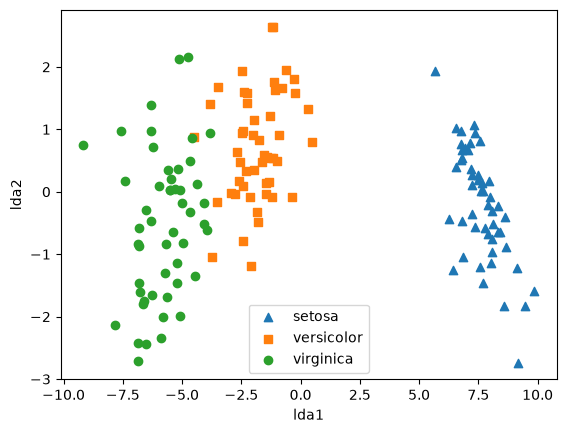

In [3]:
markers=['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_lda[irisDF_lda['target']==i]['lda1']
    y_axis_data = irisDF_lda[irisDF_lda['target']==i]['lda2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel('lda1')
plt.ylabel('lda2')
plt.show()

### SVD(Singular Value Decomposition)
 - 아이리스 데이터 SVD 실습

In [4]:
from sklearn.decomposition import TruncatedSVD

tsvd = TruncatedSVD(n_components = 2)
tsvd.fit(iris_scaled)
iris_tsvd = tsvd.transform(iris_scaled)
tsvd_columns=['tsvd1','tsvd2']
irisDF_tsvd = pd.DataFrame(iris_tsvd, columns = tsvd_columns)
irisDF_tsvd['target']=iris.target
irisDF_tsvd.head()

,tsvd1,tsvd2,target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0


In [5]:
tsvd.explained_variance_ratio_

array([0.72962445, 0.22850762])

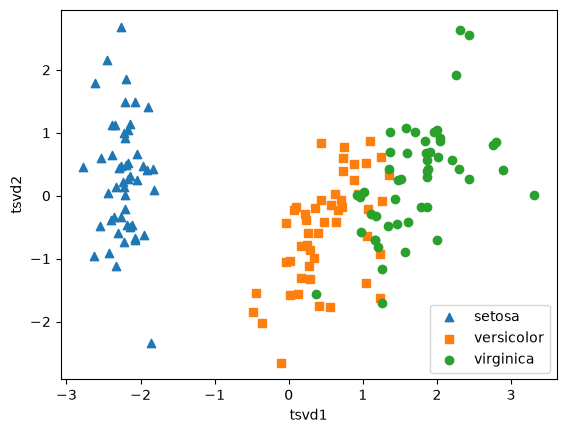

In [6]:
markers=['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_tsvd[irisDF_tsvd['target']==i]['tsvd1']
    y_axis_data = irisDF_tsvd[irisDF_tsvd['target']==i]['tsvd2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel('tsvd1')
plt.ylabel('tsvd2')
plt.show()

### NMF(Non-Negative Matrix Factorization)
 - 아이리스 데이터 NMF 실습

In [7]:
from sklearn.decomposition import NMF

nmf = NMF(n_components= 2)
nmf.fit(iris.data)
iris_nmf = nmf.transform(iris.data)
nmf_columns=['nmf1','nmf2']
irisDF_nmf = pd.DataFrame(iris_nmf, columns = nmf_columns)
irisDF_nmf['target']=iris.target
irisDF_nmf.head()

c:\Users\samsung1\git_project\samsung_practice\.venv\Lib\site-packages\sklearn\decomposition\_nmf.py:1723: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


,nmf1,nmf2,target
0,0.413500,0.104673,0
1,0.365449,0.140978,0
2,0.377800,0.101885,0
3,0.349981,0.148964,0
4,0.415896,0.095306,0


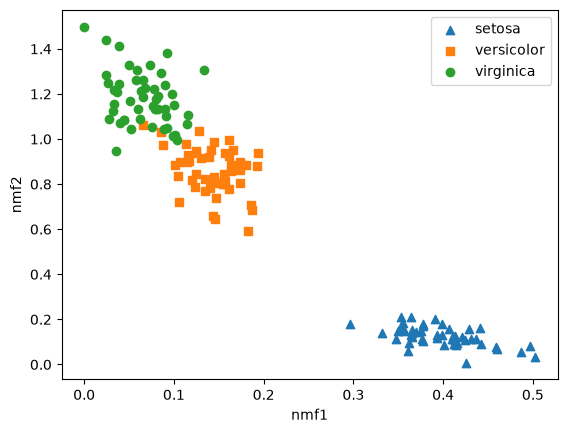

In [8]:
markers=['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_nmf[irisDF_nmf['target']==i]['nmf1']
    y_axis_data = irisDF_nmf[irisDF_nmf['target']==i]['nmf2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel('nmf1')
plt.ylabel('nmf2')
plt.show()

### t-SNE(t-Distributed Stochastic Neighor Embedding)
 - 아이리스 데이터 t-SNE 실습

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components = 2, random_state = 0, perplexity = 30)
iris_tsne = tsne.fit_transform(iris_scaled)
tsne_columns=['tsne1','tsne2']
irisDF_tsne = pd.DataFrame(iris_tsne, columns = tsne_columns)
irisDF_tsne['target'] = iris.target

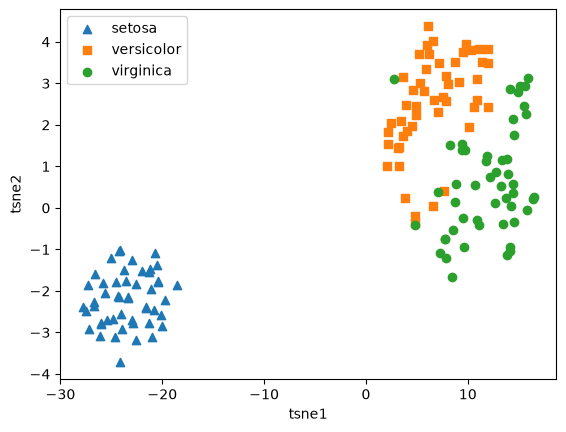

In [10]:
markers=['^', 's', 'o']
for i, marker in enumerate(markers):
    x_axis_data = irisDF_tsne[irisDF_tsne['target']==i]['tsne1']
    y_axis_data = irisDF_tsne[irisDF_tsne['target']==i]['tsne2']
    plt.scatter(x_axis_data, y_axis_data, marker=marker, label=iris.target_names[i])
plt.legend()
plt.xlabel('tsne1')
plt.ylabel('tsne2')
plt.show()

## 실습(PCA)

In [ ]:
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer()
pd.DataFrame(cancer.data, columns=cancer.feature_names)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, cancer.target, 
                                                    test_size=0.2, random_state=0)


In [15]:
# 로지스틱 회귀 모델을 사용해서 차원축소 vs 원본
from sklearn.decomposition import PCA

pca = PCA(n_components = X_scaled.shape[1])
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_)

[4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
 5.49576849e-02 4.02452204e-02 2.25073371e-02 1.58872380e-02
 1.38964937e-02 1.16897819e-02 9.79718988e-03 8.70537901e-03
 8.04524987e-03 5.23365745e-03 3.13783217e-03 2.66209337e-03
 1.97996793e-03 1.75395945e-03 1.64925306e-03 1.03864675e-03
 9.99096464e-04 9.14646751e-04 8.11361259e-04 6.01833567e-04
 5.16042379e-04 2.72587995e-04 2.30015463e-04 5.29779290e-05
 2.49601032e-05 4.43482743e-06]


In [ ]:
total_ratio = 0
for i, ratio in enumerate(pca.explained_variance_ratio_):
    total_ratio += ratio
    if total_ratio >= 0.85:
        print(i + 1)
        break

# 결과는 6
# 위 결과인 
# 4.42720256e-01 1.89711820e-01 9.39316326e-02 6.60213492e-02
# 5.49576849e-02 4.02452204e-02까지 더해야 85%이상이라는 뜻

6


In [21]:
X_train_p, X_test_p = train_test_split(X_pca[:, :6], test_size=0.2, random_state=0)

In [ ]:
from  sklearn.linear_model import LogisticRegression

lr_clf = LogisticRegression(random_state=0)
lr_clf2 = LogisticRegression(random_state=0)
lr_clf.fit(X_train, y_train)
lr_clf2.fit(X_train_p, y_train)
pred = lr_clf.predict(X_test)
pred2 = lr_clf2.predict(X_test_p)

In [25]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

print('오차행렬 :')
print(confusion_matrix(y_test, pred))
print(f'정확도 : {accuracy_score(y_test, pred):.4f}')
print(f'정밀도 : {precision_score(y_test, pred):.4f}')
print(f'재현율 : {recall_score(y_test, pred):.4f}')
print(f'F1스코어 : {f1_score(y_test, pred):.4f}')

오차행렬 :
[[45  2]
 [ 2 65]]
정확도 : 0.9649
정밀도 : 0.9701
재현율 : 0.9701
F1스코어 : 0.9701


In [26]:
print('오차행렬 :')
print(confusion_matrix(y_test, pred2))
print(f'정확도 : {accuracy_score(y_test, pred2):.4f}')
print(f'정밀도 : {precision_score(y_test, pred2):.4f}')
print(f'재현율 : {recall_score(y_test, pred2):.4f}')
print(f'F1스코어 : {f1_score(y_test, pred2):.4f}')

오차행렬 :
[[44  3]
 [ 2 65]]
정확도 : 0.9561
정밀도 : 0.9559
재현율 : 0.9701
F1스코어 : 0.9630


<Axes: >

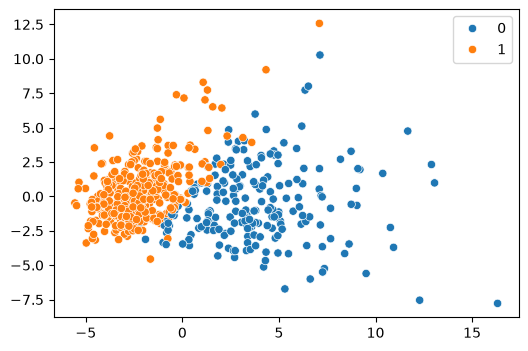

In [29]:
import seaborn as sns

X = X_pca[:, :2]
y = cancer.target
plt.figure(figsize=(6, 4))
sns.scatterplot(x = X[:, 0], y = X[:, 1], hue=y)